# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [260]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [261]:
# TODO: Import all necessary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [262]:
# Set seed
np.random.seed(42)

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [263]:
# Loading the dataset
df = pd.read_csv('/content/drive/MyDrive/phitronEvaluations/ML/Assignment3/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [264]:
# showing shape
# The dataset consists of 1338 rows along with 7 features
df.shape

(1338, 7)

In [265]:
# column names
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [266]:
# charges is the target column since it description it is clearly stated that "Can you accurately predict insurance costs"
# Thus, we are trying to predict the medical insurance cost for each of the individuals which is represented by the feature charges.
features = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
target = 'charges'

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [267]:
# TODO: Perform EDA

In [268]:
# dtype and nan value count all the columns
# the df contains no missing values and the features are of a mix of numerical and categorical features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [269]:
# descriptive statistics for numeric columns
# done to understand distibution / spread of the dataset
# The features have different scale especially charges which shows a large range variance compared to rest of the numerical features.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [270]:
numeric_cols = ['age', 'bmi', 'children']
categorical_cols = ['sex', 'smoker', 'region']

In [271]:
# computing correlation matrix
# children shows a very small impact with the target variable.
# age and bmi both shows weak correlation with the target.
corr_matrix = df[numeric_cols + [target]].corr()
corr_matrix

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


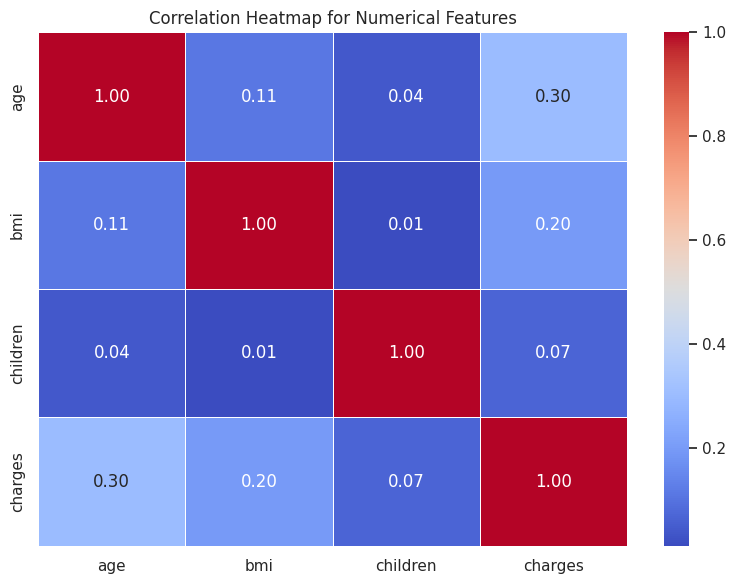

In [272]:
# plottign correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

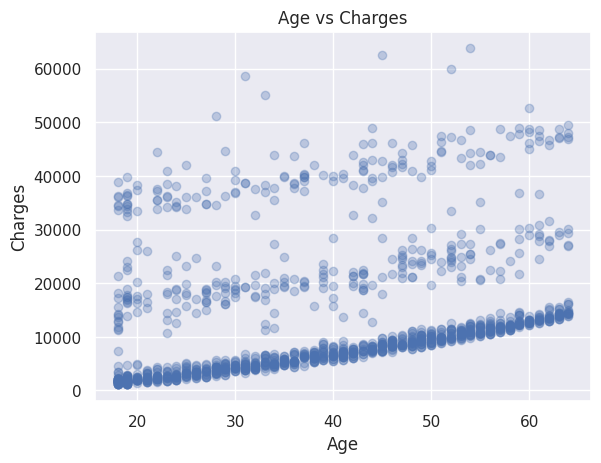

In [273]:
# plot of age vs target
# there is a upward trend indicating that with increasing age, medical charges also increases
plt.scatter(df['age'], df['charges'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.grid(True)
plt.show()

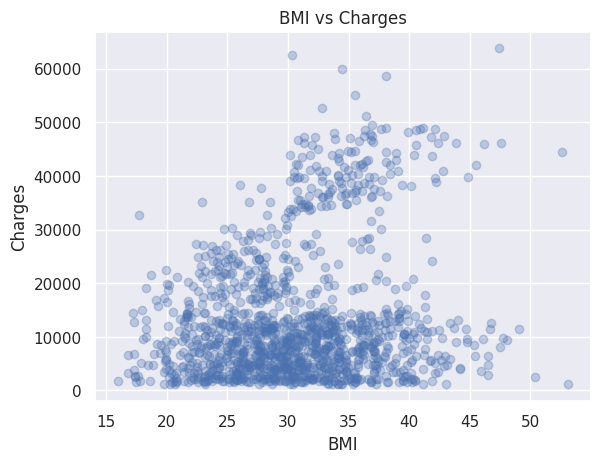

In [274]:
# High BMI somewhat indicates higher medical charges
# But not a strong relation as it can be seen in the plot.
plt.scatter(df['bmi'], df['charges'], alpha=0.3)
plt.xlabel('BMI')
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.grid(True)
plt.show()

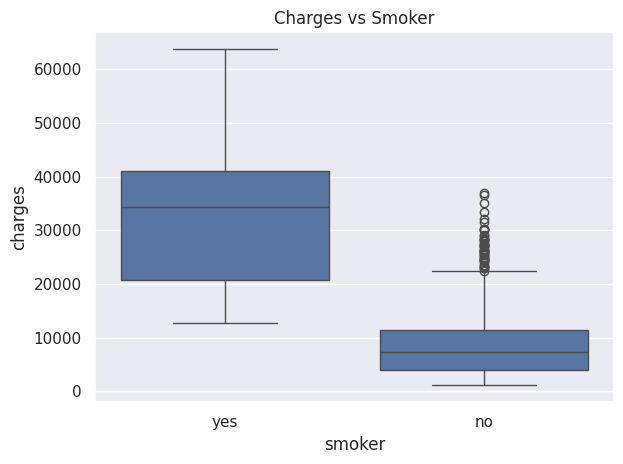

In [275]:
# Smokers have a considerably higher medical charges compared to its counter part
sns.boxplot(data=df, x='smoker', y='charges')
plt.title("Charges vs Smoker")
plt.tight_layout()
plt.show()

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [276]:
# TODO: Prepare features
X = df[features]
y = df[target]

In [277]:
# Train-Test Split
# with 20% of data for testing and rest 80% of data for training
# fixed random state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [278]:
# Scaling
# since the numerical features are on varied scales so to bring them on a common scale standard scaling was applied
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols])

X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [279]:
# label encoding the sex and smoker feature since they are binary features
le = LabelEncoder()

le.fit(X_train[['sex']])
X_train['sex'] = le.transform(X_train['sex'])
X_test['sex'] = le.transform(X_test['sex'])

le.fit(X_train[['smoker']])
X_train['smoker'] = le.transform(X_train['smoker'])
X_test['smoker'] = le.transform(X_test['smoker'])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [280]:
# One Hot encoding region since it is a nominal feature
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe.fit(X_train[['region']])

# X_train
encodedRegionTrain = ohe.transform(X_train[['region']])
region_df_train = pd.DataFrame(
    encodedRegionTrain,
    columns = ohe.get_feature_names_out(['region']),
    index = X_train.index
)
X_train = X_train.drop('region', axis=1)
X_train = pd.concat([X_train, region_df_train], axis=1)

# X_test
encodedRegionTest = ohe.transform(X_test[['region']])
region_df_test = pd.DataFrame(
    encodedRegionTest,
    columns = ohe.get_feature_names_out(['region']),
    index = X_test.index
)
X_test = X_test.drop('region', axis=1)
X_test = pd.concat([X_test, region_df_test], axis=1)

In [281]:
X_train

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
560,0.472227,0,-1.756525,0.734336,0,1.0,0.0,0.0
1285,0.543313,0,-1.033082,-0.911192,0,0.0,0.0,0.0
1142,0.898745,0,-0.943687,-0.911192,0,0.0,1.0,0.0
969,-0.025379,0,0.622393,3.202629,0,0.0,1.0,0.0
486,1.040918,0,-1.504893,1.557100,0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1095,-1.518194,0,0.130717,2.379865,0,0.0,0.0,0.0
1130,-0.025379,0,-1.107579,3.202629,0,0.0,1.0,0.0
1294,1.325264,1,-0.891539,-0.911192,0,0.0,0.0,0.0
860,-0.167551,0,2.820864,0.734336,1,0.0,0.0,1.0


In [282]:
X_test

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
764,0.401140,0,-0.891539,0.734336,0,0.0,0.0,0.0
887,-0.238638,0,-0.089461,-0.911192,0,1.0,0.0,0.0
890,1.751782,0,-0.608453,-0.911192,1,1.0,0.0,0.0
1293,0.472227,1,-0.797177,1.557100,0,1.0,0.0,0.0
259,-1.447107,1,0.225079,-0.911192,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
109,1.680696,1,0.749865,-0.911192,1,0.0,1.0,0.0
575,1.325264,0,-0.561272,-0.911192,0,1.0,0.0,0.0
535,-0.096465,1,-0.419729,-0.088428,0,0.0,0.0,0.0
543,1.040918,0,2.789410,-0.911192,1,0.0,1.0,0.0


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [283]:
# TODO: Multiple Linear Regression

In [284]:
# Model train
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [285]:
# Inspecting Learned Parameters
# Intercept
print(f"Intercept (bias term): {lr.intercept_}")

Intercept (bias term): 8955.244801502882


In [286]:
# Coefficients
for feature_name, coef in zip(X_train.columns, lr.coef_):
  print(f"{feature_name} : {coef}")

age : 3614.9754148280003
sex : -18.59169164101195
bmi : 2036.228122896716
children : 516.8902471991574
smoker : 23651.12885576125
region_northwest : -370.6773262278089
region_southeast : -657.8642965646395
region_southwest : -809.7993541824717


In [287]:
# predicting data on both train as well as test set
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [288]:
def regression_metrics(y_true, y_pred, label='Model'):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'=== {label} ====')
  print('MAE: ', mae)
  print('RMSE: ', rmse)
  print('R2 : ', r2)
  print()

# Evaluate on train and test
regression_metrics(y_train, y_train_pred, label='Linear Regression (Train)')
regression_metrics(y_test, y_test_pred, label='Linear Regression (Test)')

=== Linear Regression (Train) ====
MAE:  4208.234572492224
RMSE:  6105.545160099847
R2 :  0.7417255854683333

=== Linear Regression (Test) ====
MAE:  4181.194473753649
RMSE:  5796.284659276274
R2 :  0.7835929767120722



In [289]:
# MAE and RMSE shows moderate error
# R2 shows that the model can explain significant variance on the test data set implying the model to be good
# R2 of train and test data shows close results so no overfitting.
# since both of the R2 is closer to 1 so the model is not underfitting either.

## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [290]:
# TODO: Polynomial Regression

In [291]:
degrees = [1, 2, 3, 4, 5]
results = []

for deg in degrees:

  pr = Pipeline([
      ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
      ('lin_reg', LinearRegression())
  ])

  pr.fit(X_train, y_train)

  y_train_pred_deg = pr.predict(X_train)
  y_test_pred_deg = pr.predict(X_test)

  mae_train = mean_absolute_error(y_train, y_train_pred_deg)
  rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_deg))
  r2_train = r2_score(y_train, y_train_pred_deg)

  mae_test = mean_absolute_error(y_test, y_test_pred_deg)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_deg))
  r2_test = r2_score(y_test, y_test_pred_deg)

  results.append({
      'degree'     : deg,
      'mae_train'  : mae_train,
      'rmse_train' : rmse_train,
      'r2_train'   : r2_train,

      'mae_test'  : mae_test,
      'rmse_test' : rmse_test,
      'r2_test'   : r2_test,
  })

results_df = pd.DataFrame(results)
results_df

,degree,mae_train,rmse_train,r2_train,mae_test,rmse_test,r2_test
0,1,4208.234572,6105.545160,0.741726,4181.194474,5796.284659,0.783593
1,2,2892.149840,4778.187803,0.841817,2729.500134,4551.132385,0.866583
2,3,2792.779239,4575.510839,0.854952,2937.918593,4847.496055,0.848641
3,4,2626.010631,4236.764886,0.875634,3529.077571,6177.256538,0.754211
4,5,2243.716989,3675.691713,0.906392,5511.901796,14006.247327,-0.263617


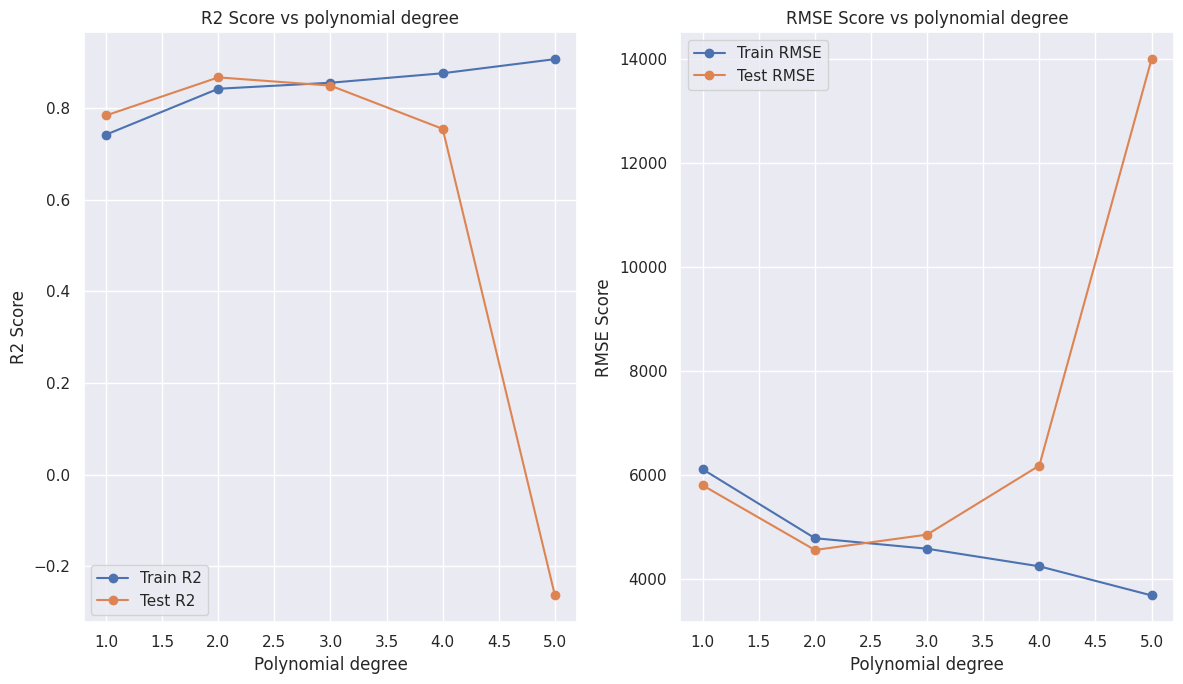

In [292]:
# Plot R squared and RMSE vs polynomial degree
fig, axes = plt.subplots(1,2, figsize=(12,7))


# R squared plot
axes[0].plot(results_df['degree'], results_df['r2_train'],marker='o',label='Train R2')
axes[0].plot(results_df['degree'], results_df['r2_test'],marker='o',label='Test R2')
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("R2 Score")
axes[0].set_title("R2 Score vs polynomial degree")
axes[0].legend()

# RMSE plot
axes[1].plot(results_df['degree'], results_df['rmse_train'],marker='o',label='Train RMSE')
axes[1].plot(results_df['degree'], results_df['rmse_test'],marker='o',label='Test RMSE')
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("RMSE Score")
axes[1].set_title("RMSE Score vs polynomial degree")
axes[1].legend()

plt.tight_layout()
plt.show()

In [293]:
# With increasing degree, the performance of the training data set increases where r2 reaches closer to 1 and rmse decreases consistently.
# But, training set only performs upto degree 2 and then its performance starts degrading.
# So, degree 2 gives the best possible possible performance indicating it captured non-linear relationships effectively
# With increasing degree, the model starts overfitting on the test set as it can be seen that r2 increases consistently in the
# training set but on the otherhand decreases on the testing set with each degree.
# Polynomial Regression with degree 2 performs better than that of just Multiple linear regression
# R2 in polynomial (degree2) is 86.7 whereas in multiple linear regression it was around 74.5
# Likewise, rmse in polynomial regression is 4551.1 whereas is multiple linear regression it is approx 5796.3. Again, a significant
# lower error in polynomial
# As a result, it can be concluded that, the relationship between the features and target were not linear and have non-linear relations.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [294]:
# TODO: Support Vector Regression

In [295]:
svr = SVR(kernel='rbf', C=4000.0, epsilon=250.0, gamma='scale')
svr.fit(X_train, y_train)

SVR(C=4000.0, epsilon=250.0)

In [296]:
y_pred_svr = svr.predict(X_test)
y_pred_svr

array([ 9264.12367579,  5367.66403979, 26954.67005988,  9436.77199979,
       23427.3614935 ,  4712.89135702,  2389.23359883, 14041.12258364,
        4241.39703791, 10501.41930691, 17367.56249314,  7281.59171596,
        3728.76933189, 36136.15107861, 38882.19518917, 45380.82736335,
       10060.36969491, 45294.58799851,  8086.52980552, 22297.23673235,
        6155.06396486,  7610.61866264,  1517.71317262,  2825.29858018,
       11107.19678533, 11187.96175905, 12879.26793711,  5378.32748211,
        9845.59931222,  1216.28241415,  8180.63475991, 11990.73604946,
        2142.58375255,  6340.41904122,  2968.4357779 ,  7659.55458516,
        2485.67251411,  7410.0236625 , 22985.4892755 , 41763.36228324,
        5752.66893849,  2598.02368325, 12056.34119816, 12297.35740306,
        5085.09659005, 12515.65437029,  4266.02831966,  4627.53943436,
       38035.36266253,  4769.67210368, 13987.7668733 ,  1727.80621621,
        6998.83371583,  1798.40543722, 10940.73421337, 10282.06345152,
      

In [297]:
# Mean Absolute Error
mean_absolute_error(y_test, y_pred_svr)

2194.2639472911524

In [298]:
# Mean Squared Error
mean_squared_error(y_test, y_pred_svr)

28999303.602307122

In [299]:
# Root Mean Square Error
np.sqrt(mean_squared_error(y_test, y_pred_svr))

np.float64(5385.100147843782)

In [300]:
# R2 Score
r2_score(y_test, y_pred_svr)

0.8132074682758759

In [301]:
# RBF kernel can capture non-linear relationships between features and the target.
# Here, since the target variable i.e. charges relies on complex interaction between its features like age, sex, bmi, children, smoker, region
# therefore, a non-linear kernel is more appropriate to capture such complex patters which a linear model won't be able to achieve.
# Also, SVR performed better than regression suggesting further about the non-linear relationships

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [302]:
# TODO: Random Forest Regressor

In [303]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [304]:
y_pred_rfr = rfr.predict(X_test)
y_pred_rfr

array([ 9627.2160164 ,  5570.1966765 , 28239.6470855 , 12462.6824866 ,
       34640.8607121 ,  8312.863145  ,  2105.641873  , 14566.8640467 ,
        5627.8743072 , 10798.4897132 , 19475.6350362 ,  7248.018148  ,
        4710.4406919 , 46115.816236  , 48310.4323983 , 45480.1572698 ,
        9934.559207  , 43592.4934467 ,  8901.9920937 , 24486.9093416 ,
        8548.0619393 , 10577.3370178 ,  1820.1056351 ,  2136.5048955 ,
       11826.623556  , 11905.5511078 , 13253.3064705 ,  7663.1146887 ,
       10916.4927344 ,  7058.09038378,  8278.3984302 , 11750.559285  ,
        2982.1268703 ,  5734.7199683 ,  3833.1672093 ,  9821.986748  ,
        2821.0419754 ,  8059.511844  , 23799.6731765 , 39510.0300355 ,
        5882.027899  ,  4233.5238216 , 11877.1047977 , 14612.6730822 ,
        5691.045522  , 14855.9042835 , 15597.2375983 ,  8836.5771471 ,
       42101.7246104 ,  8251.9057    , 13970.305623  ,  2699.5943685 ,
        7073.5166805 ,  1901.24840265, 13409.2263522 , 10618.1452764 ,
      

In [305]:
# Mean Absolute Error
mean_absolute_error(y_test, y_pred_rfr)

2544.9770956523676

In [306]:
# Mean Squared Error
mean_squared_error(y_test, y_pred_rfr)

20877104.681165546

In [307]:
# Root Mean Square Error
np.sqrt(mean_squared_error(y_test, y_pred_rfr))

np.float64(4569.147040878149)

In [308]:
r2_score(y_test, y_pred_rfr)

0.8655247970108418

In [309]:
# Among the regressor models, random forest regressor achieved the highest r2 score of 86.6% and lowest rmse
# The model performed well as it could campture the non-linear relation between the features and target which possess complex relation
# This further strengthens the claim of the dataset having non-linear complex patterns

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [310]:
# TODO: Load classification dataset
dfB = pd.read_csv('/content/drive/MyDrive/phitronEvaluations/ML/Assignment3/loan_data.csv')
dfB

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [311]:
featuresB = ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
targetB = 'loan_status'

In [312]:
# Class distribution
dfB[targetB].value_counts()

,count
loan_status,
0,35000
1,10000


In [313]:
dfB[targetB].value_counts(normalize=True)

,proportion
loan_status,
0,0.777778
1,0.222222


In [314]:
# the class 0 (Loan Rejected) is approximately three times more than that of 1 (Loan Approved).
# Thus, the data set is imbalanced
# with nearly 77.8% belonging to loan rejected and only 22.2% belonging to loan approved.
# Since the data set is heavily imbalanced, it will bias the model towards predicting the majority class.
# As a result, the evaluation metric accuracy will not be much reliable.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


In [315]:
# TODO: Classification EDA

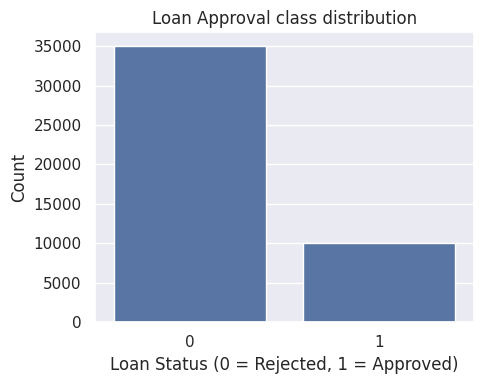

In [316]:
# Class count plot
plt.figure(figsize=(5, 4))
sns.countplot(data=dfB, x=targetB)
plt.title("Loan Approval class distribution")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

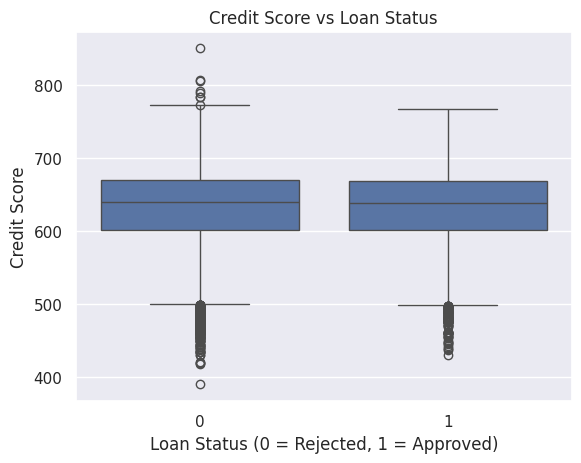

In [317]:
# Credit score vs Loan Status
sns.boxplot(data=dfB, x=targetB, y='credit_score')
plt.title("Credit Score vs Loan Status")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Credit Score")
plt.show()

In [318]:
# The higher the credit score is, the more chances of Loan approval increases

In [319]:
# previous loan defaults on file vs loan status
pd.crosstab(dfB['previous_loan_defaults_on_file'], dfB[targetB])

loan_status,0,1
previous_loan_defaults_on_file,,
No,12142,10000
Yes,22858,0


In [320]:
ct = pd.crosstab(dfB['previous_loan_defaults_on_file'], dfB[targetB], normalize=True)
ct

loan_status,0,1
previous_loan_defaults_on_file,,
No,0.269822,0.222222
Yes,0.507956,0.000000


In [321]:
# Applicants with previous loan defaults on file are always rejected
# This implies a feature of high influence.

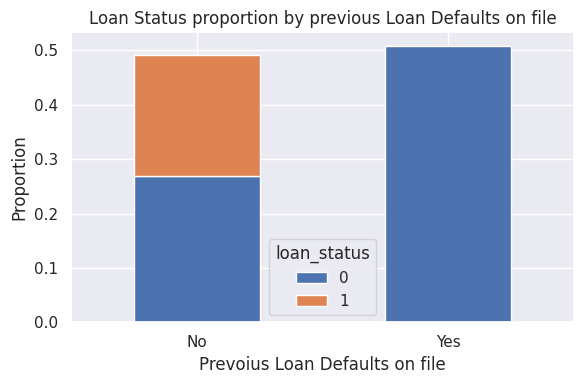

In [322]:
ct.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Loan Status proportion by previous Loan Defaults on file")
plt.ylabel("Proportion")
plt.xlabel("Prevoius Loan Defaults on file")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [323]:
# TODO: Prepare classification features

In [324]:
Xb = dfB[featuresB]
yb = dfB[targetB]

In [325]:
# train test split
X_trainB, X_testB, y_trainB, y_testB = train_test_split(Xb, yb, test_size=0.2, stratify=yb)
# As there is class imbalance, stratify was used to preserve the distribution of the target variable.

In [326]:
# Encoding

In [327]:
categorical_colsB = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
numerical_colsB = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

In [328]:
# Encoding person_gender
X_trainB['person_gender'] = X_trainB['person_gender'].map({
    'male'   :  1,
    'female' :  0,
})

X_testB['person_gender'] = X_testB['person_gender'].map({
    'male'   :  1,
    'female' :  0,
})

In [329]:
# Encoding previous_loan_defaults_on_file
X_trainB['previous_loan_defaults_on_file'] = X_trainB['previous_loan_defaults_on_file'].map({
    'Yes' : 1,
    'No'  : 0,
})

X_testB['previous_loan_defaults_on_file'] = X_testB['previous_loan_defaults_on_file'].map({
    'Yes' : 1,
    'No'  : 0,
})

In [330]:
# OHE is being used to avoid introducing ordinal relationships
# Encoding ['person_education', 'person_home_ownership', 'loan_intent'] using OHE
oheB = OneHotEncoder(drop='first', sparse_output=False)
oheB.fit(X_trainB[['person_education', 'person_home_ownership', 'loan_intent']])

OneHotEncoder(drop='first', sparse_output=False)

In [331]:
# transforming X_trainB
encodedTrainB = oheB.transform(X_trainB[['person_education', 'person_home_ownership', 'loan_intent']])

df_trainB = pd.DataFrame(
    encodedTrainB,
    columns = oheB.get_feature_names_out(['person_education', 'person_home_ownership', 'loan_intent']),
    index = X_trainB.index,
)

X_trainB = X_trainB.drop(['person_education', 'person_home_ownership', 'loan_intent'], axis=1)
X_trainB = pd.concat([X_trainB, df_trainB], axis=1)

In [332]:
# transforming X_testB
encodedtestB = oheB.transform(X_testB[['person_education', 'person_home_ownership', 'loan_intent']])

df_testB = pd.DataFrame(
    encodedtestB,
    columns = oheB.get_feature_names_out(['person_education', 'person_home_ownership', 'loan_intent']),
    index = X_testB.index,
)

X_testB = X_testB.drop(['person_education', 'person_home_ownership', 'loan_intent'], axis=1)
X_testB = pd.concat([X_testB, df_testB], axis=1)

In [333]:
# Scaling numerical features
# The numerical features are on different scale. Thus, were standardized so that they all can contribute equally to the model
# prevent dominance of any large valued feature
scalerB = StandardScaler()
scalerB.fit(X_trainB[numerical_colsB])

StandardScaler()

In [334]:
# transforming both training and testing dataset
X_trainB[numerical_colsB] = scalerB.transform(X_trainB[numerical_colsB])
X_testB[numerical_colsB] = scalerB.transform(X_testB[numerical_colsB])

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [335]:
# TODO: Logistic Regression

In [336]:
lr_l2 = LogisticRegression(
    penalty='l2',
    tol=0.001,
    solver='liblinear',
    max_iter=100,
    multi_class='auto',
    random_state=42
)

lr_l2.fit(X_trainB, y_trainB)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='auto', random_state=42, solver='liblinear',
                   tol=0.001)

In [337]:
y_pred_lr_l2 = lr_l2.predict(X_testB)
y_pred_lr_l2

array([0, 0, 0, ..., 0, 0, 0])

In [338]:
accuracy_score(y_testB, y_pred_lr_l2)

0.8994444444444445

In [339]:
precision_score(y_testB, y_pred_lr_l2)

0.7889182058047494

In [340]:
recall_score(y_testB, y_pred_lr_l2)

0.7475

In [341]:
f1_score(y_testB, y_pred_lr_l2)

0.7676508344030809

In [342]:
# The model acheived a high accuracy score with good precision and recall

In [343]:
cm = confusion_matrix(y_testB, y_pred_lr_l2)
cm

array([[6600,  400],
       [ 505, 1495]])

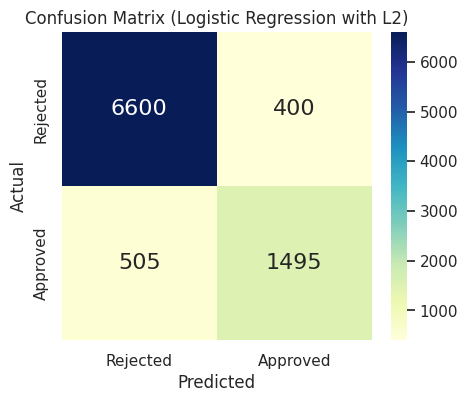

In [344]:
#Plot of Confusion Matrix
plt.figure(figsize=(5, 4))
sns.set(font_scale=1)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', annot_kws={'size': 16}, xticklabels = ["Rejected", "Approved"], yticklabels = ["Rejected", "Approved"],)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression with L2)")
plt.show()

In [345]:
# As per cm, most were correctly classified though some are misclassified

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [346]:
# TODO: SVM Classification

In [347]:
svc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
)

svc.fit(X_trainB, y_trainB)

SVC(random_state=42)

In [348]:
y_pred_svc = svc.predict(X_testB)
y_pred_svc

array([0, 0, 0, ..., 0, 0, 0])

In [349]:
accuracy_score(y_testB, y_pred_svc)

0.918

In [350]:
print(classification_report(y_testB, y_pred_svc, target_names=['0 (Rejected)', '1 (Approved)']))

              precision    recall  f1-score   support

0 (Rejected)       0.93      0.96      0.95      7000
1 (Approved)       0.85      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000



In [351]:
# SVM achieves an high accuracy which is nearly 91.8%
# It particularly does well on the 0 class i.e. rejected
# among all the evaluation metrices, recall is slightly lower for the 0 (approved) class i.e. approved cases were misclassified.

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [352]:
# TODO: Naive Bayes

In [353]:
# The dataset consists of continuous numerical features
# for this very task, GNB was the most suitable variant

In [354]:
gnb = GaussianNB()
gnb.fit(X_trainB, y_trainB)

GaussianNB()

In [355]:
y_pred_gnb = gnb.predict(X_testB)
y_pred_gnb

array([1, 0, 0, ..., 0, 0, 0])

In [356]:
# accuracy score
accuracy_score(y_testB, y_pred_gnb)

0.7532222222222222

In [357]:
# confusion matrix
cm = confusion_matrix(y_testB, y_pred_gnb)
cm

array([[4819, 2181],
       [  40, 1960]])

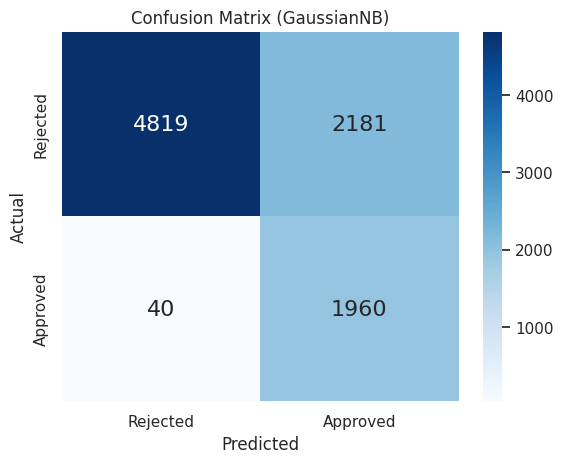

In [358]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws = {'size':16},
    xticklabels = ["Rejected", "Approved"],
    yticklabels = ["Rejected", "Approved"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (GaussianNB)")

plt.show()

In [359]:
print(classification_report(y_testB, y_pred_gnb, target_names=['0(Rejected)', '1(Approved)']))

              precision    recall  f1-score   support

 0(Rejected)       0.99      0.69      0.81      7000
 1(Approved)       0.47      0.98      0.64      2000

    accuracy                           0.75      9000
   macro avg       0.73      0.83      0.73      9000
weighted avg       0.88      0.75      0.77      9000



In [360]:
# As far as approved loans are concerned, the model achieved a very high recall values but a low precision value.
# so many loans were predicted as approved eventhough in reality they were rejected which increase false positives.
# the model seems to be biased towards approved class since 2181 false positives were found.
# so it can be said that the model is biased towards the minority class.

## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [361]:
# TODO: KNN

In [362]:
accuracy_lst=[]
for i in range(1, 100):

  # Initialising knn classifir
  knn_c = KNeighborsClassifier(
      n_neighbors=i,
      metric='minkowski',
      p=2, # Euclidean Distance
      weights='distance',
  )

  # Fitting knn classifier
  knn_c.fit(X_trainB, y_trainB)

  # predicting
  y_pred_knn_c = knn_c.predict(X_testB)

  # Accuracy
  acc_knn_c = accuracy_score(y_testB, y_pred_knn_c)
  accuracy_lst.append(acc_knn_c)


In [363]:
accuracy_lst

[0.8733333333333333,
 0.8733333333333333,
 0.8912222222222222,
 0.8913333333333333,
 0.8997777777777778,
 0.8987777777777778,
 0.8993333333333333,
 0.9013333333333333,
 0.902,
 0.9027777777777778,
 0.9032222222222223,
 0.9041111111111111,
 0.9021111111111111,
 0.9035555555555556,
 0.9034444444444445,
 0.9044444444444445,
 0.9021111111111111,
 0.9037777777777778,
 0.9037777777777778,
 0.9033333333333333,
 0.9026666666666666,
 0.9045555555555556,
 0.9041111111111111,
 0.9046666666666666,
 0.904,
 0.9033333333333333,
 0.904,
 0.9052222222222223,
 0.9052222222222223,
 0.9044444444444445,
 0.9051111111111111,
 0.9036666666666666,
 0.9037777777777778,
 0.9042222222222223,
 0.905,
 0.9044444444444445,
 0.9051111111111111,
 0.9042222222222223,
 0.9046666666666666,
 0.904,
 0.9036666666666666,
 0.9044444444444445,
 0.9043333333333333,
 0.9043333333333333,
 0.9041111111111111,
 0.9041111111111111,
 0.9028888888888889,
 0.9033333333333333,
 0.9034444444444445,
 0.9033333333333333,
 0.904,
 0.9038

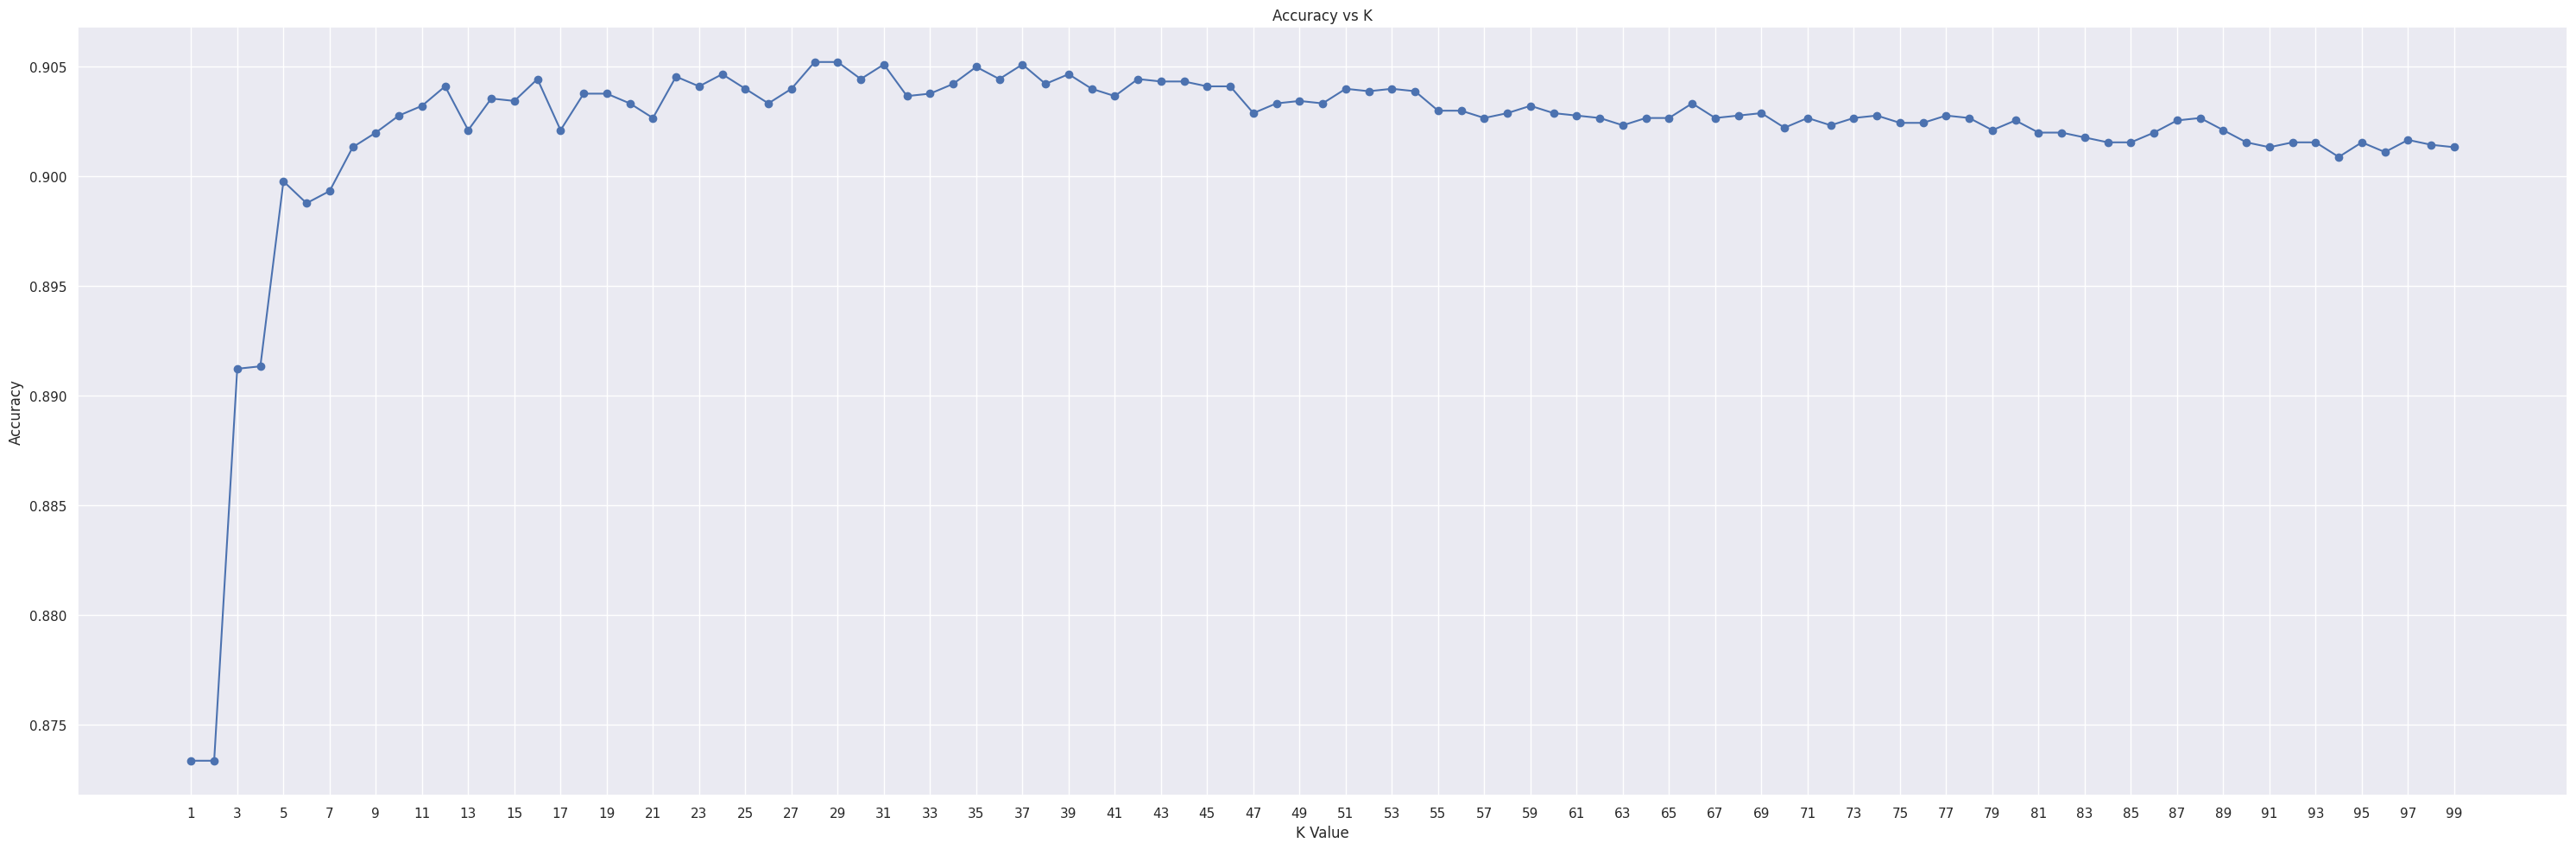

In [364]:
plt.figure(figsize=(30, 10))
plt.plot(range(1, 100), accuracy_lst, marker='o')
plt.xticks(range(1, 100, 2))
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.tight_layout()
plt.show()

In [365]:
# Around k = 28-31, the model achieves the best performance where the accuracy reaches beyond 90.5%
# With an increasing value of k, accuracy increases until it stabilizes. After that, with an increasing k, accuracy slightly decreases.
# Since, a small value of k leads to overfitting and a large value of k leads to underfitting, so a moderate value of k like 28-31 is preferred

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [366]:
# TODO: Random Forest Classifier

In [367]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_trainB, y_trainB)

RandomForestClassifier(random_state=42)

In [368]:
y_pred_rfc = rfc.predict(X_testB)
y_pred_rfc

array([0, 0, 0, ..., 0, 0, 0])

In [369]:
accuracy_score(y_testB, y_pred_rfc)

0.9283333333333333

In [370]:
pd.Series(rfc.feature_importances_, index=X_trainB.columns).sort_values(ascending=False)

,0
previous_loan_defaults_on_file,0.220573
loan_int_rate,0.156885
loan_percent_income,0.154772
person_income,0.131130
loan_amnt,0.063453
person_home_ownership_RENT,0.055722
credit_score,0.054739
person_age,0.031676
person_emp_exp,0.028114
cb_person_cred_hist_length,0.026377


In [371]:
# The most important feature happens to be previous_loan_defaults_on_file. This suggests behaviour of loans taken previously have a strong
# influence whether future loan application will be approved or not. After this feature, the second most important feature is loan_int_rate where
# feature importance decreases substantially from 0.220573 to 0.156885. Nevertheless, loan_int_rate, loan_percent_income, person_income still
# possess to be strong determiners.
# On the other hand, features like education, intent, education have very low importance suggesting that they have minimal impact on loan decisions.

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here

In [375]:
# ==== Best regression model and why ====
# In this assignment, the best regression model has to be polynomial regression with degree 2 which has the highest r2 value of 86.6%.
# It slightly outperformed Random Forest Regressor which had nearly identical performance.
# In practice, Random Forest Regressor is more stable in real world data pattern making it more reliable.
# However, in this scenarion, polynomial regressior was able to capture a bit more non-linear relation outperforming random forest regressor

# ==== One real-world deployment scenario ====
# A insurance company can use this to predict insurance charges for a customer based on the applicants age, sex, bmi, children, smoker, region
# It can set and offer realistic insurance plans based on the outcome of prediction for that customer
# It will know how much funds to allocate for a customer with such attributes.

In [374]:
# ==== Best classification model and why ====
# The best classification model has to be Random Forest since it achieved the highest accuracy i.e. 92.8 among all the models that were trained.
# It furthermore, provided meaningful feature importance and handled feature interactions which was quite accurate in terms of real world scenario.

# ==== One real-world deployment scenario ====
# Banking loan application system.
# If this model is deployed in such a scenario, it can increase efficiency by reducing manual effort since it can assest the bank in deciding
# whether a loan application should be approved or rejected as it takes into consideration important features like income, credit score,
# previous loan defaults on file etc just like a real world scenario.